In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from IPython.display import display, Markdown

In [2]:
df = pd.read_csv("diabetic_data.csv", low_memory=False)

In [3]:
df.shape

(101766, 50)

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Garbage cleaning

### Standardizing column names (lowercase, replace spaces with underscores)

In [8]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

### Replacing ? with NaN

In [10]:
df.replace("?", np.nan, inplace=True)

### Checking if there are any duplicate rows

In [12]:
duplicate_rows = df.duplicated()
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

Number of duplicate rows: 0


### removing the unuseful features(columns)

In [14]:
df.drop(columns=["encounter_id", "patient_nbr"], inplace=True) #columns with unique values

### Checking to see which columns have null values

In [16]:
df.isnull().sum()

race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
a1cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

## Handeling missing values

### the "race" columns

In [19]:
df.sample(10)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesmed,readmitted
100156,Caucasian,Female,[60-70),NaN,2,5,7,6,CM,Emergency/Trauma,...,No,No,No,No,No,No,No,No,No,>30
1591,Caucasian,Male,[80-90),NaN,1,3,7,4,NaN,Pulmonology,...,No,Up,No,No,No,No,No,Ch,Yes,>30
89101,AfricanAmerican,Female,[60-70),NaN,1,1,7,3,OG,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,>30
24677,Hispanic,Female,[40-50),NaN,1,6,7,1,NaN,Family/GeneralPractice,...,No,No,No,No,No,No,No,No,No,NO
61377,Caucasian,Female,[80-90),NaN,1,1,7,6,MC,NaN,...,No,No,No,No,No,No,No,No,No,NO
85014,Caucasian,Male,[90-100),NaN,1,3,7,4,MC,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,<30
55673,AfricanAmerican,Female,[70-80),NaN,2,6,1,7,NaN,Pathology,...,No,No,No,No,No,No,No,No,No,>30
37670,Caucasian,Male,[70-80),NaN,1,1,7,1,NaN,InternalMedicine,...,No,Steady,No,No,No,No,No,Ch,Yes,>30
55447,AfricanAmerican,Male,[60-70),NaN,1,3,7,12,MC,NaN,...,No,Down,No,No,No,No,No,Ch,Yes,<30
99326,Caucasian,Male,[50-60),NaN,1,1,7,7,SP,NaN,...,No,No,No,No,No,No,No,No,No,NO


In [20]:
df["race"].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

<Axes: >

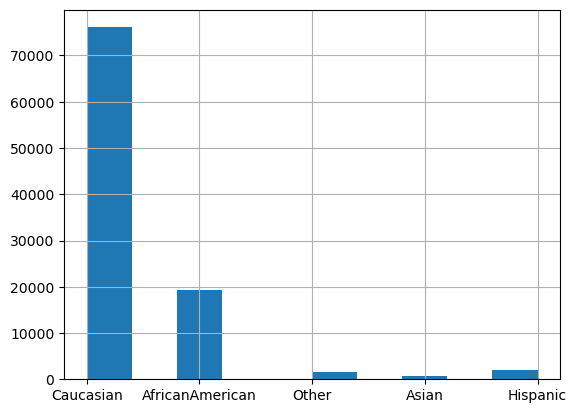

In [21]:
df["race"].hist()

In [22]:
df["race"].isnull().sum()

2273

In [23]:
### filling the  missing values with the most frequently occurring value (mode 0)

In [24]:
df["race"].fillna(df["race"].mode() [0], inplace = True)

C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\41588938.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["race"].fillna(df["race"].mode() [0], inplace = True)


### 👍🙂

In [26]:
df["race"].isnull().sum()

0

#### We can see the number of Caucasians have increased 

<Axes: >

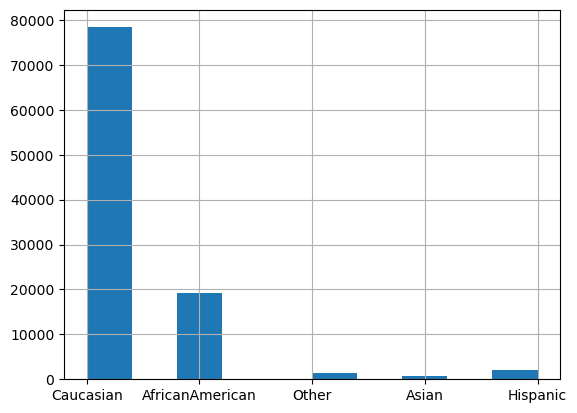

In [28]:
df["race"].hist()

### the "age" column

In [30]:
df["age"].value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

 #### converting the ranges to the middle of that range

In [32]:
def mean_of_range(age_range):
    if isinstance(age_range, str) and '[' in age_range and ')' in age_range:
        age_range = age_range.strip('[)')  # Remove brackets
        low, high = map(int, age_range.split('-'))
        return (low + high) / 2 # mean of the range
    return age_range  # Return as is if not a valid range

df['age'] = df['age'].apply(mean_of_range)

### 🙂👍

<Axes: xlabel='age'>

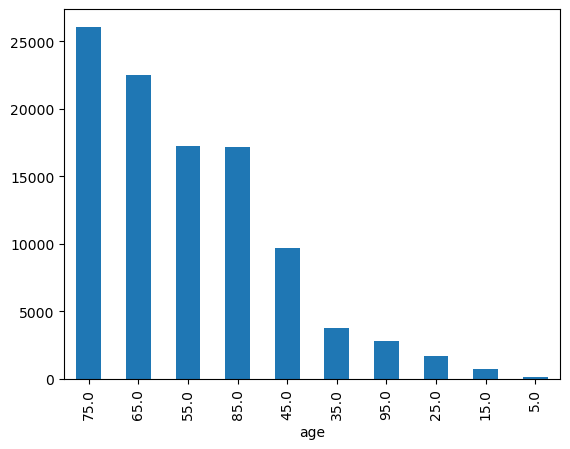

In [34]:
df["age"].value_counts().plot.bar()

In [35]:
df["age"].isnull().sum()

0

In [36]:
df.isnull().sum()

race                            0
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
a1cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

### the "weight" column

<Axes: >

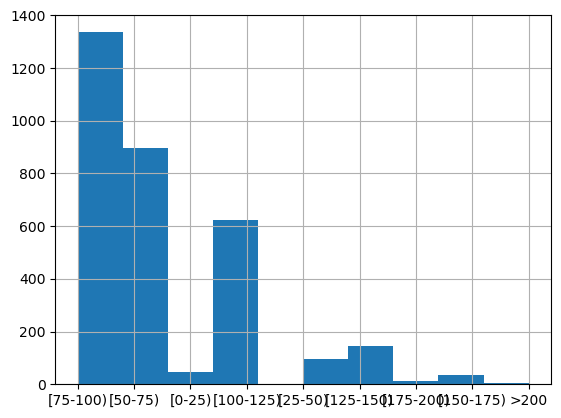

In [38]:
df["weight"].hist()

In [39]:
df["weight"].value_counts()

weight
[75-100)     1336
[50-75)       897
[100-125)     625
[125-150)     145
[25-50)        97
[0-25)         48
[150-175)      35
[175-200)      11
>200            3
Name: count, dtype: int64

 #### converting the ranges to the middle of that range

In [41]:
df['weight'] = df['weight'].apply(mean_of_range) #using the same function made in last part

#### becuase the number of >200 is only 3 we could just replace it with 200 to maintain consistency

In [43]:
df["weight"].replace(">200", 200, inplace=True) 

C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\827673861.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["weight"].replace(">200", 200, inplace=True)
C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\827673861.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["weight"].replace(">200",

<Axes: xlabel='weight'>

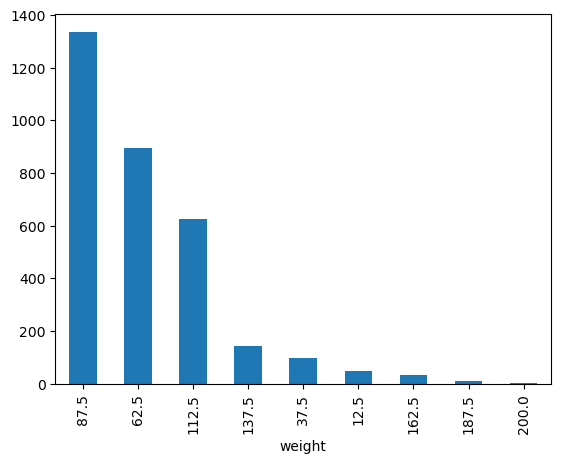

In [44]:
df["weight"].value_counts().plot.bar()

#### fixing the missing values

In [46]:
df["weight"].isnull().sum()

98569

In [47]:
df["weight"].describe()

count    3197.000000
mean       86.268377
std        26.034565
min        12.500000
25%        62.500000
50%        87.500000
75%       112.500000
max       200.000000
Name: weight, dtype: float64

In [48]:
df["weight"].median()

87.5

#### since the number of NaNs are high, we could replace them with the median of the column

In [50]:
df["weight"].fillna(df["weight"].median(), inplace = True)

In [51]:
df["weight"].isnull().sum()

0

In [52]:
df.head(10)


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesmed,readmitted
0,Caucasian,Female,5.0,87.5,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,15.0,87.5,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,25.0,87.5,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,35.0,87.5,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,45.0,87.5,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,Caucasian,Male,55.0,87.5,2,1,2,3,NaN,NaN,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,Caucasian,Male,65.0,87.5,3,1,2,4,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,Caucasian,Male,75.0,87.5,1,1,7,5,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,>30
8,Caucasian,Female,85.0,87.5,2,1,4,13,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,Caucasian,Female,95.0,87.5,3,3,4,12,NaN,InternalMedicine,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [53]:
df.isnull().sum()

race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
a1cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

### the "payer_code" column

In [55]:
df["payer_code"].value_counts()

payer_code
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

#### replacing the nulls with a new category "no insurance"

In [57]:
df["payer_code"].fillna("no insurance", inplace = True)

C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\4137384437.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["payer_code"].fillna("no insurance", inplace = True)


In [58]:
df["payer_code"].value_counts()

payer_code
no insurance    40256
MC              32439
HM               6274
SP               5007
BC               4655
MD               3532
CP               2533
UN               2448
CM               1937
OG               1033
PO                592
DM                549
CH                146
WC                135
OT                 95
MP                 79
SI                 55
FR                  1
Name: count, dtype: int64

In [59]:
df["payer_code"].isnull().sum()

0

### the "medical_speciality" column

In [61]:
df["medical_specialty"].value_counts()

medical_specialty
InternalMedicine                    14635
Emergency/Trauma                     7565
Family/GeneralPractice               7440
Cardiology                           5352
Surgery-General                      3099
                                    ...  
Perinatology                            1
Neurophysiology                         1
Psychiatry-Addictive                    1
Pediatrics-InfectiousDiseases           1
Surgery-PlasticwithinHeadandNeck        1
Name: count, Length: 72, dtype: int64

<Axes: >

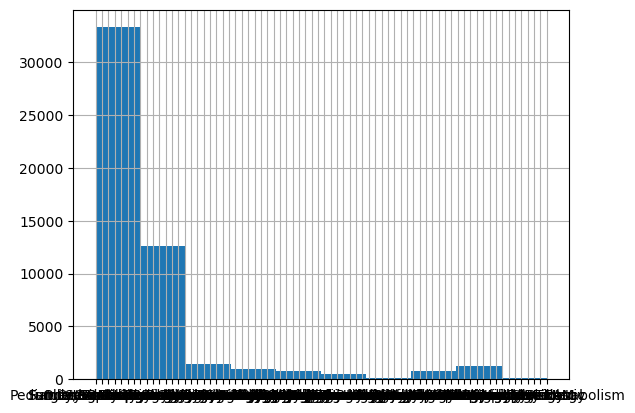

In [62]:
df["medical_specialty"].hist()

#### replacing the nulls with a new category "no specialty"

In [64]:
df["medical_specialty"].fillna("no specialty", inplace = True)

C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\1326913112.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["medical_specialty"].fillna("no specialty", inplace = True)


In [65]:
df["medical_specialty"].value_counts()

medical_specialty
no specialty                     49949
InternalMedicine                 14635
Emergency/Trauma                  7565
Family/GeneralPractice            7440
Cardiology                        5352
                                 ...  
SportsMedicine                       1
Speech                               1
Perinatology                         1
Neurophysiology                      1
Pediatrics-InfectiousDiseases        1
Name: count, Length: 73, dtype: int64

### cleaning the "diag1" column

In [67]:
df["diag_1"].describe()

count     101745
unique       716
top          428
freq        6862
Name: diag_1, dtype: object

#### when looking at the dataset the three diag columns must be all numbers, but as we can see in the info they are shown as "object" meaning there are not all numbers.

In [69]:
df["diag_1"] = pd.to_numeric(df["diag_1"], errors = 'coerce') #If convertible to a number, stays as a number.
# If not convertible, becomes NaN.

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   race                      101766 non-null  object 
 1   gender                    101766 non-null  object 
 2   age                       101766 non-null  float64
 3   weight                    101766 non-null  float64
 4   admission_type_id         101766 non-null  int64  
 5   discharge_disposition_id  101766 non-null  int64  
 6   admission_source_id       101766 non-null  int64  
 7   time_in_hospital          101766 non-null  int64  
 8   payer_code                101766 non-null  object 
 9   medical_specialty         101766 non-null  object 
 10  num_lab_procedures        101766 non-null  int64  
 11  num_procedures            101766 non-null  int64  
 12  num_medications           101766 non-null  object 
 13  number_outpatient         101766 non-null  i

In [71]:
df["diag_2"] = pd.to_numeric(df["diag_2"], errors = 'coerce')

In [72]:
df["diag_3"] = pd.to_numeric(df["diag_3"], errors = 'coerce')

In [73]:
df["diag_1"].describe()

count    100100.00000
mean        493.58307
std         206.71532
min           3.00000
25%         410.00000
50%         440.00000
75%         599.00000
max         999.00000
Name: diag_1, dtype: float64

<Axes: xlabel='diag_1'>

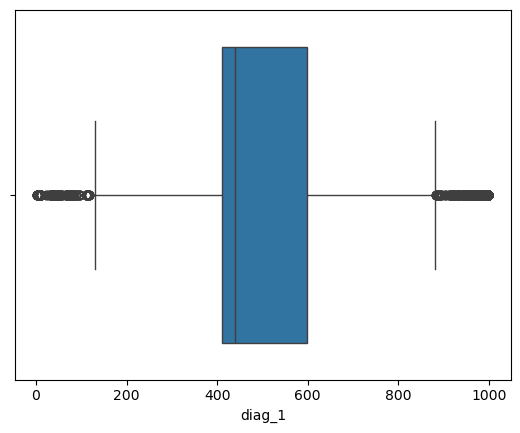

In [74]:
sns.boxplot(x = 'diag_1', data = df)

#### replacing the NaNs with the median of the column

In [76]:
df["diag_1"].fillna(df["diag_1"].median(), inplace = True)

C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\3943146427.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["diag_1"].fillna(df["diag_1"].median(), inplace = True)


In [77]:
df["diag_2"].fillna(df["diag_2"].median(), inplace = True)

C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\3180666766.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["diag_2"].fillna(df["diag_2"].median(), inplace = True)


In [78]:
df["diag_3"].fillna(df["diag_3"].median(), inplace = True)

C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\1539718132.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["diag_3"].fillna(df["diag_3"].median(), inplace = True)


<Axes: xlabel='diag_2'>

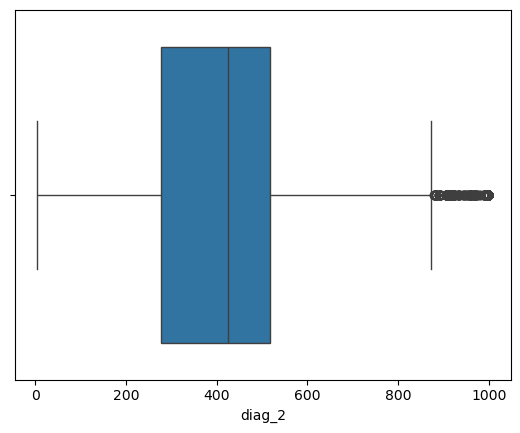

In [79]:
sns.boxplot(x = 'diag_2', data = df)

<Axes: xlabel='diag_3'>

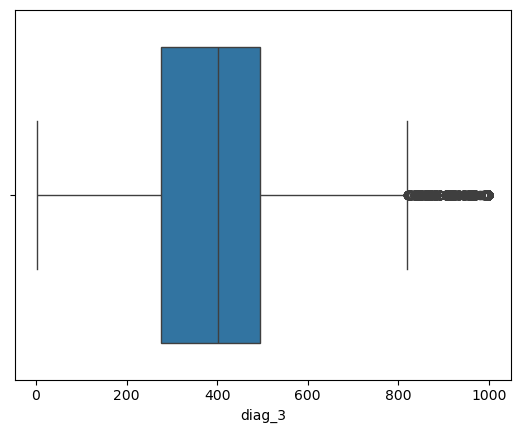

In [80]:
sns.boxplot(x = 'diag_3', data = df)

### the max_glu_serum" column

In [82]:
df["max_glu_serum"].value_counts()

max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64

<Axes: xlabel='max_glu_serum'>

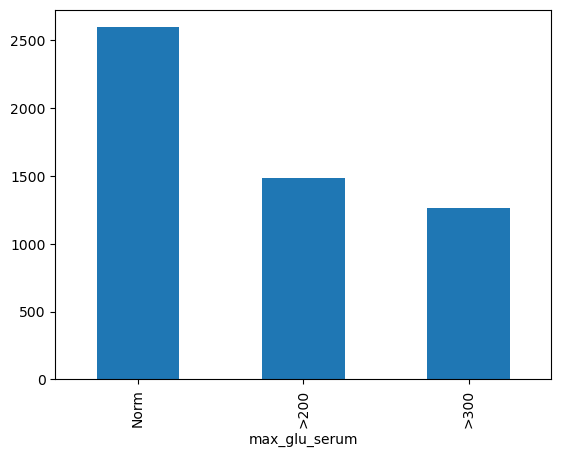

In [83]:
df["max_glu_serum"].value_counts().plot.bar()

#### since the number of NaNs are high we'll put them with a new category "unknown"

In [85]:
df["max_glu_serum"].fillna("Unknown", inplace = True)

C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\2725803892.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["max_glu_serum"].fillna("Unknown", inplace = True)


<Axes: xlabel='max_glu_serum'>

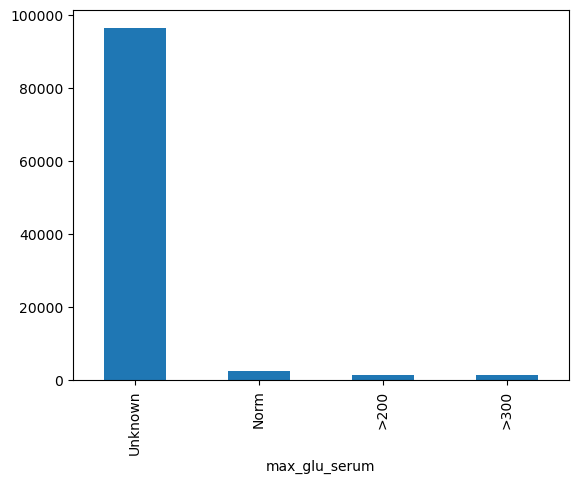

In [86]:
df["max_glu_serum"].value_counts().plot.bar()

### the "a1cresult" column

In [88]:
df["a1cresult"].value_counts()

a1cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64

#### since the number of NaNs are high we'll put them with a new category "unknown"

In [90]:
df["a1cresult"].fillna("Unknown", inplace = True)

C:\Users\Owner\AppData\Local\Temp\ipykernel_12324\2925535670.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["a1cresult"].fillna("Unknown", inplace = True)


In [91]:
df["a1cresult"].value_counts()

a1cresult
Unknown    84748
>8          8216
Norm        4990
>7          3812
Name: count, dtype: int64

<Axes: xlabel='a1cresult'>

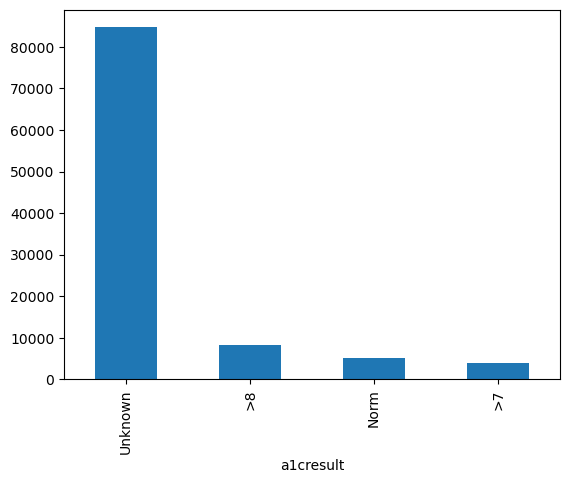

In [92]:
df["a1cresult"].value_counts().plot.bar()

### no more missing or duplicate values👍

In [94]:
df.isnull().sum()

race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
a1cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose  

### all the columns are in the correct type

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   race                      101766 non-null  object 
 1   gender                    101766 non-null  object 
 2   age                       101766 non-null  float64
 3   weight                    101766 non-null  float64
 4   admission_type_id         101766 non-null  int64  
 5   discharge_disposition_id  101766 non-null  int64  
 6   admission_source_id       101766 non-null  int64  
 7   time_in_hospital          101766 non-null  int64  
 8   payer_code                101766 non-null  object 
 9   medical_specialty         101766 non-null  object 
 10  num_lab_procedures        101766 non-null  int64  
 11  num_procedures            101766 non-null  int64  
 12  num_medications           101766 non-null  object 
 13  number_outpatient         101766 non-null  i

## Feature transformation and scaling

#### This converts a continuous variable (number_emergency) into a binary feature (emegency_history) which then makes teh analysis easier

In [99]:
df["emegency_history"] = df["number_emergency"].apply(lambda x:0 if x==0 else 1)

In [100]:
df = df.drop(columns = ["number_emergency"])

#### creating a new column "diag" by calculating the mean of the columns "diag_1", "diag_2", and "diag_3"

In [102]:
diag_columns = ["diag_1", "diag_2", "diag_3"]
df["diag"] = df[diag_columns].mean(axis=1)

In [103]:
df[["diag_1", "diag_2", "diag_3", "diag"]].head()

,diag_1,diag_2,diag_3,diag
0,250.83,425.00,403.0,359.610000
1,276.00,250.01,255.0,260.336667
2,648.00,250.00,403.0,433.666667
3,8.00,250.43,403.0,220.476667
4,197.00,157.00,250.0,201.333333


#### getting rid of the 3 diag columns

In [105]:
df = df.drop(columns = diag_columns)

In [106]:
df[["diag"]].head()

,diag
0,359.610000
1,260.336667
2,433.666667
3,220.476667
4,201.333333


## detecting and removing outliers

In [108]:
outlier_info = {}

# Iterate over all numeric columns
for col in df.select_dtypes(include=['number']).columns:
    Q1 = df[col].quantile(0.25)  # 25th percentile
    Q3 = df[col].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile range

    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count number of outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not outliers.empty:
        outlier_info[col] = (lower_bound, upper_bound)

print("Columns with potential outliers:", list(outlier_info.keys()))

Columns with potential outliers: ['age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'number_outpatient', 'number_inpatient', 'number_diagnoses', 'emegency_history', 'diag']


#### creating a fuction that defines outliers identified above

In [110]:
def remove_outliers(df, outlier_info):
    for col, (lower_bound, upper_bound) in outlier_info.items():
        # thresholds in the previous block
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    print("Outliers removed from columns:", list(outlier_info.keys()))
    return df

# removing outliers
df = remove_outliers(df, outlier_info)

Outliers removed from columns: ['age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'number_outpatient', 'number_inpatient', 'number_diagnoses', 'emegency_history', 'diag']


## Removing Outliers from `age`

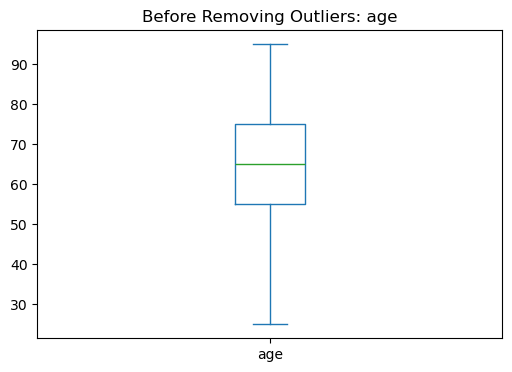

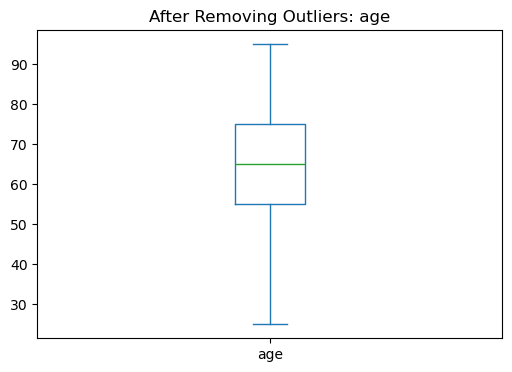

** Outliers removed from `age`!**

## Removing Outliers from `weight`

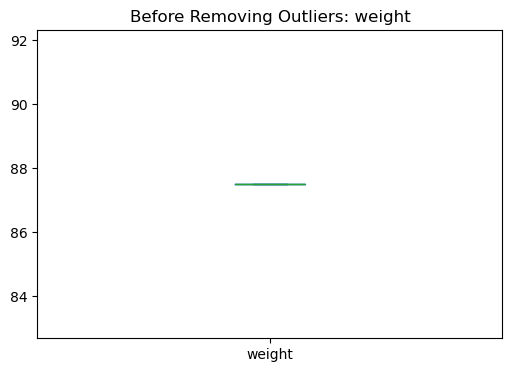

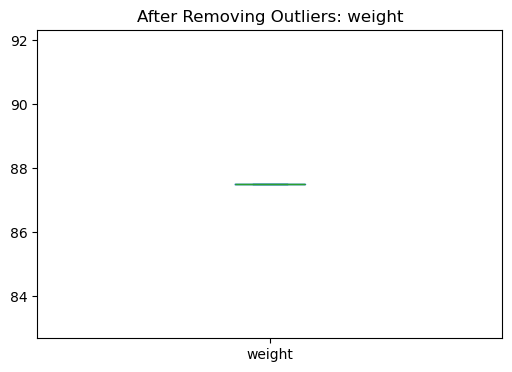

** Outliers removed from `weight`!**

## Removing Outliers from `admission_type_id`

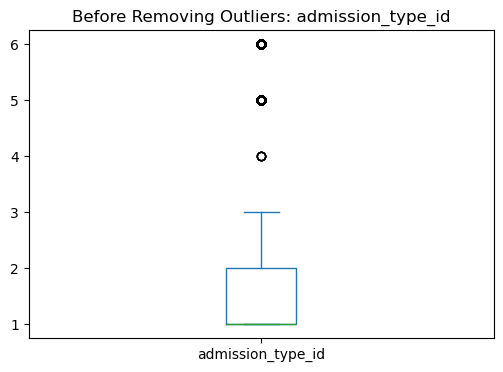

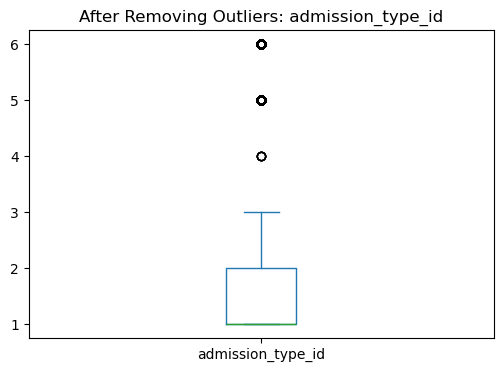

** Outliers removed from `admission_type_id`!**

## Removing Outliers from `discharge_disposition_id`

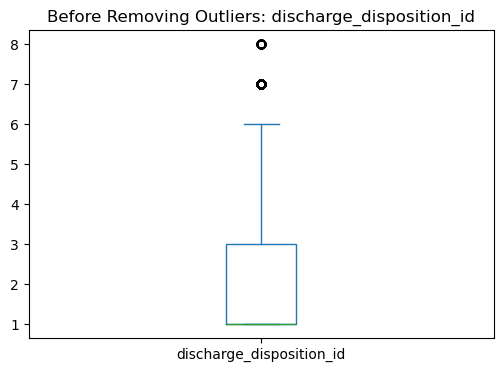

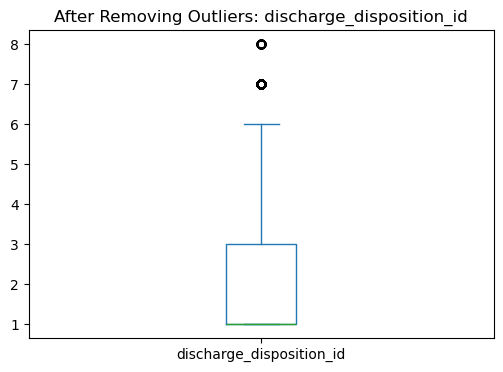

** Outliers removed from `discharge_disposition_id`!**

## Removing Outliers from `admission_source_id`

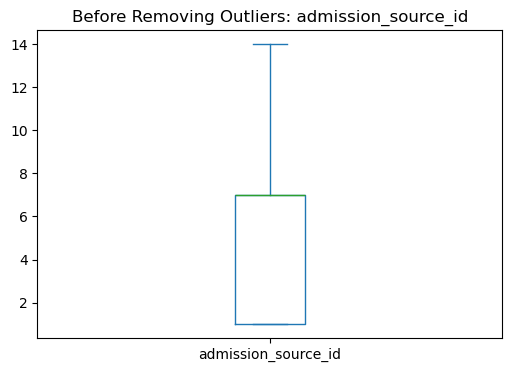

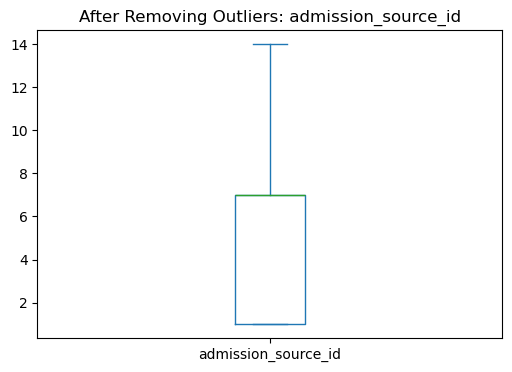

** Outliers removed from `admission_source_id`!**

## Removing Outliers from `time_in_hospital`

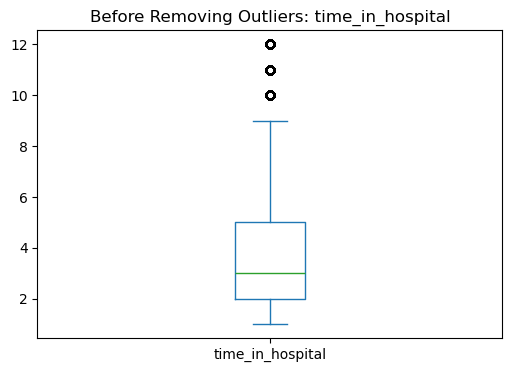

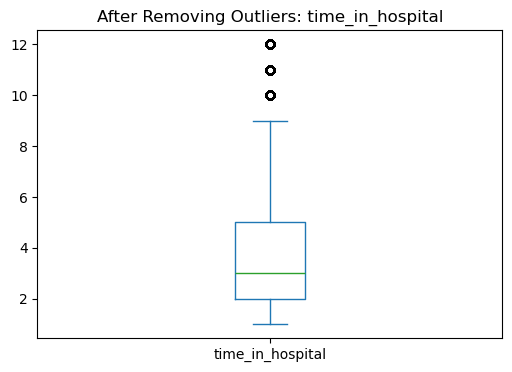

** Outliers removed from `time_in_hospital`!**

## Removing Outliers from `num_lab_procedures`

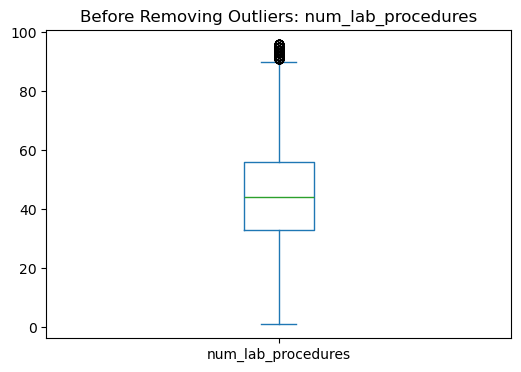

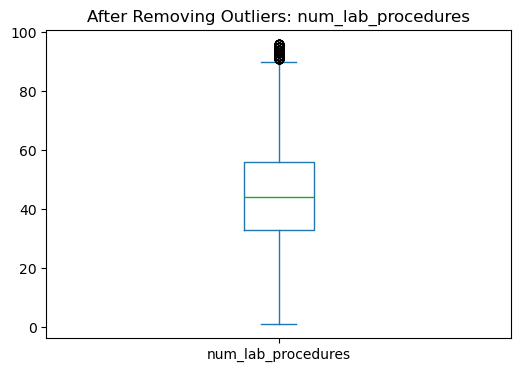

** Outliers removed from `num_lab_procedures`!**

## Removing Outliers from `num_procedures`

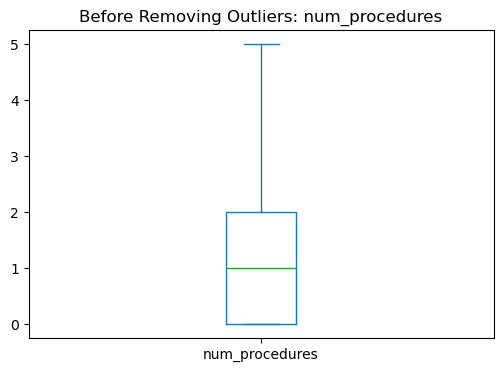

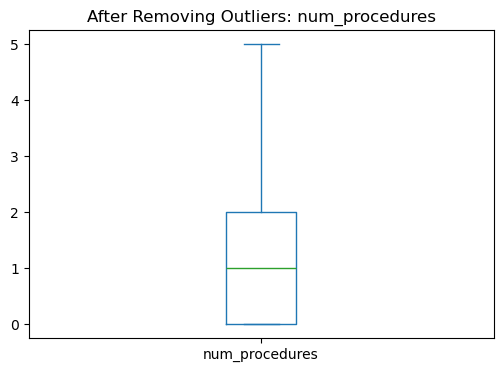

** Outliers removed from `num_procedures`!**

## Removing Outliers from `number_outpatient`

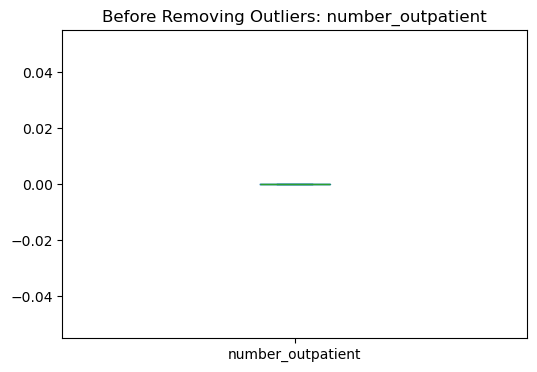

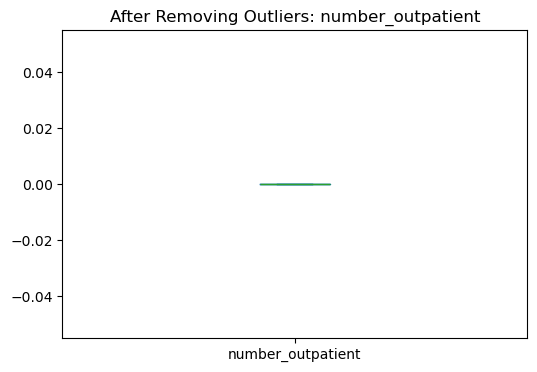

** Outliers removed from `number_outpatient`!**

## Removing Outliers from `number_inpatient`

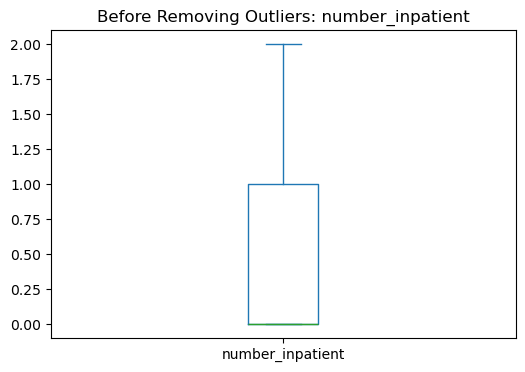

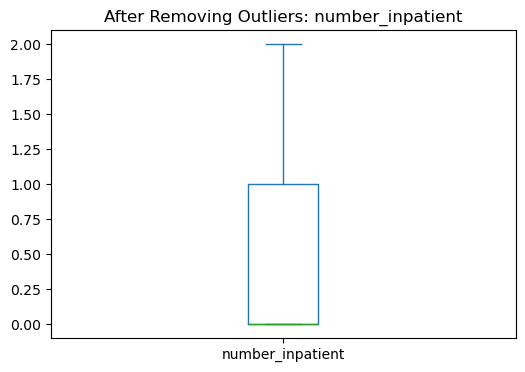

** Outliers removed from `number_inpatient`!**

## Removing Outliers from `number_diagnoses`

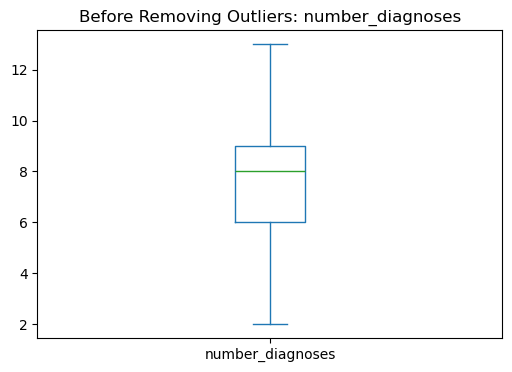

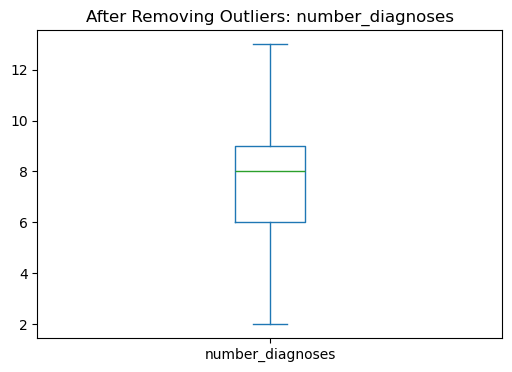

** Outliers removed from `number_diagnoses`!**

## Removing Outliers from `emegency_history`

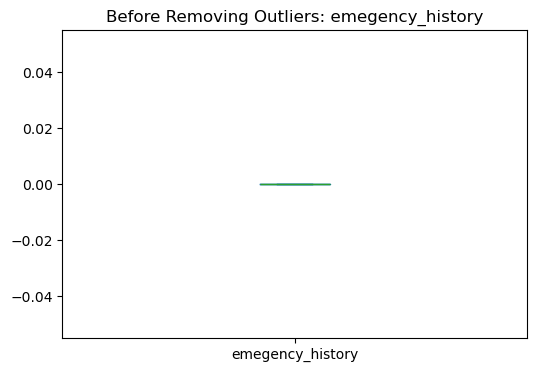

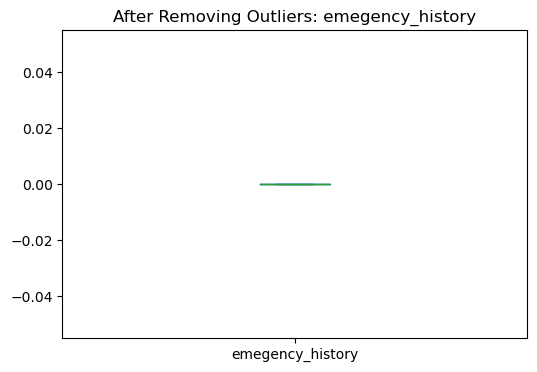

** Outliers removed from `emegency_history`!**

## Removing Outliers from `diag`

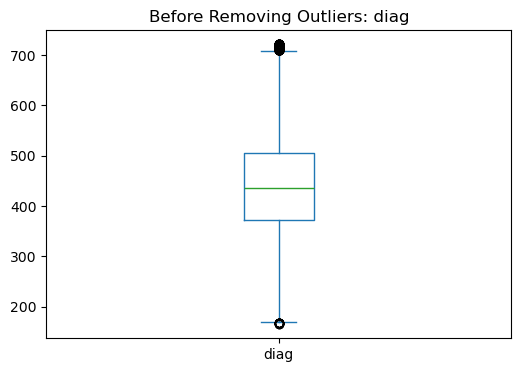

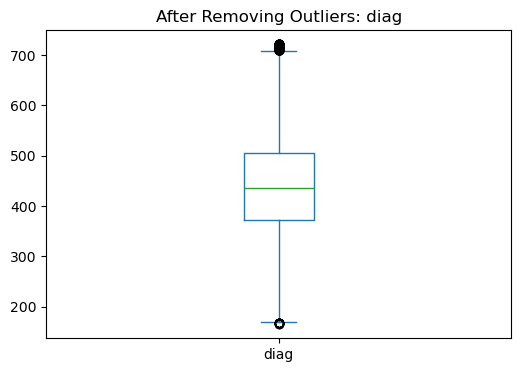

** Outliers removed from `diag`!**

**Outliers removed**

In [111]:
# Iterate through each column and remove outliers one by one
for col in outlier_info.keys(): 
    
    # Markdown for each column
    display(Markdown(f"## Removing Outliers from `{col}`"))
    
    # boxplot before removing outliers
    plt.figure(figsize=(6,4))
    df[col].plot(kind='box', title=f"Before Removing Outliers: {col}")
    plt.show()
    
    # Remove outliers using the thresholds
    lower_bound, upper_bound = outlier_info[col]  # Get stored threshold values
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    # boxplot after removing outliers
    plt.figure(figsize=(6,4))
    df[col].plot(kind='box', title=f"After Removing Outliers: {col}")
    plt.show()
    
    display(Markdown(f"** Outliers removed from `{col}`!**"))

display(Markdown("**Outliers removed**"))

In [112]:
df.shape

(55394, 46)

## Dependent and independent feature identification & Dimensionality reduction on independent features


### readmitted ---> This column indicates whether the patient was readmitted to the hospital ---> Dependent

### payer_code and medical_specialty ---> These columns do not provide useful information for prediction

In [216]:
df.drop(columns=["payer_code", "medical_specialty"], inplace=True)

#### the remaining features are independent and will effect the target feature 

In [220]:
df.shape

(55394, 44)

#### saving the cleaned version

In [225]:
df.to_csv("cleaned_diabetes_data.csv", index=False)